# MCMC for hierarchical Bayesian models

**Day 3, 11:00 — 60 minutes.** Alexander Fengler (with Brandon Turner).

Yesterday afternoon we saw posteriors that were hard because they were
**correlated** — a long thin ridge, but the same shape everywhere. Hierarchical
models bring a nastier relative: **curvature that changes as you move**. No
single step size works everywhere, and the failure is not slowness. It is
*bias*.

<details class="sbi-note">
<summary>▶️ <b>Running this on Google Colab</b></summary>

The cell below is a no-op on your own machine. On Colab it installs the stack
and downloads the shared helper module, which lives one directory up in the
repository and is therefore not importable there.

Expect the install to take a few minutes. If Colab asks you to restart the
runtime, do it and then run the cell again — the second run is a no-op.

</details>

In [1]:
# --- Google Colab bootstrap; does nothing anywhere else ---------------------
import importlib.util, subprocess, sys, urllib.error, urllib.request

IN_COLAB = importlib.util.find_spec("google.colab") is not None

# `main` once this is merged; the branch is the fallback so the Colab path can
# be tested BEFORE the merge, when main does not yet have these files.
_REFS = ("main", "afengler.tutorials")
_RAW = "https://raw.githubusercontent.com/stefanradev93/sbi4cogsci/{ref}/tutorials/"


def _fetch(module):
    for ref in _REFS:
        try:
            urllib.request.urlretrieve(_RAW.format(ref=ref) + module, module)
            return ref
        except urllib.error.HTTPError:
            continue
    raise RuntimeError(f"could not fetch {module} from any of {_REFS}")


if IN_COLAB:
    # numba>=0.61 is REQUIRED, not cosmetic. pytensor resolves linker="auto" to
    # its numba backend, and numba renamed FunctionModel's first field
    # addr -> c_addr in 0.61. Colab preinstalls an older numba, and pytensor
    # declares numba only as an optional extra, so pip leaves it in place and
    # any MvNormal (SolveTriangular has no C implementation) dies with
    # KeyError: "FunctionModel does not have a field named 'c_addr'".
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "numba>=0.61", "pymc>=6.2", "arviz>=1.2", "hssm>=0.4", "pymc-extras>=0.11"],
                   check=True)
    # `dot` is a system binary, not a Python package.
    subprocess.run(["apt-get", "-qq", "install", "-y", "graphviz"],
                   check=True)
    for _mod in ["sbi4cogsci_style.py", "sbi4cogsci_figures.py"]:
        print(f"  fetched {_mod} from {_fetch(_mod)}")
    print("Colab setup done.")

In [2]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-hierarchy"))
rng = np.random.default_rng(RANDOM_SEED)

DRAWS, TUNE, CHAINS = 1000, 1000, 4

print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 6.2.0 | arviz 1.2.0


## 1. Why a hierarchy at all?

Most of this session is about a *problem* hierarchical models create — so
first, what they buy you.

There are three options, and they are **one equation with three choices of a
single term**. With $G$ participants and trials $i$ within each:

$$
p(\theta_{1:G},\, \phi \mid y) \;\propto\;
\prod_{g=1}^{G} \Big[ \prod_{i} p(y_{gi} \mid \theta_g)
                      \cdot p(\theta_g \mid \phi) \Big] \cdot p(\phi)
$$

First factor the **likelihood**, second the **population** term, third the
**hyperprior**. Every argument about pooling is an argument about the middle
one:

| | population term $p(\theta_g \mid \phi)$ |
|---|---|
| **complete pooling** | a point mass — every $\theta_g$ is the same $\theta$ |
| **no pooling** | a fixed wide prior, identical and independent for each $g$ |
| **partial pooling** | a distribution whose $\phi$ is **estimated from the data** |

A hierarchy is not a new inference rule — it is the ordinary posterior with one
extra layer in the prior. What changes is that participants stop being
independent: each estimate now depends on what the others said, through $\phi$.

Complete pooling is what you are doing whenever you aggregate across
participants and fit once, and it is wrong the moment participants differ. The
other two are the interesting comparison.

Motivating setting: **unbalanced** data across participants. Some
participants completed hundreds of trials, some barely turned up.

In [3]:
import sbi4cogsci_figures as F      # the shared figure module

pool = F.pooling_experiment(seed=RANDOM_SEED)
counts = pool["trial_counts"]
print(f"{counts.size} participants, {pool['n_trials_total']} trials total")
print(f"trials per participant: {counts.min()} to {counts.max()}")
print(f"  the five thinnest: {sorted(counts)[:5]}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu_v, tau_v, z_off]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


20 participants, 3081 trials total
trials per participant: 5 to 600
  the five thinnest: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]


Each participant has their own drift rate, drawn from a population. We fit the
same data twice, **no pooling** and **partial pooling**, and compare both
against the drift rates we actually used. `a`, `z` and `t` are held at their
true values, so the comparison is about pooling and nothing else.

In [4]:
summary = F.pooling_summary(pool)
print(f"{'':18s} {'MAE (all)':>10s} {'n < 30':>10s} {'n >= 30':>10s}")
for key, label in [("no_pooling", "no pooling"), ("partial_pooling", "partial pooling")]:
    d = summary[key]
    print(f"{label:18s} {d['mae_all']:10.3f} {d['mae_low']:10.3f} {d['mae_high']:10.3f}")
print(f"\nimprovement where trials < 30: {summary['low_n_improvement_pct']:.0f}%")

                    MAE (all)     n < 30    n >= 30
no pooling              0.158      0.265      0.051
partial pooling         0.114      0.175      0.052

improvement where trials < 30: 34%


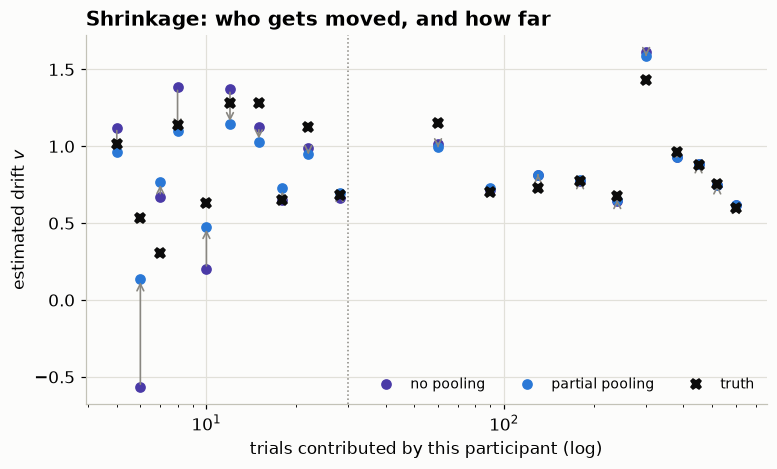

In [5]:
F.fig_shrinkage(pool)

One arrow per participant, from their no-pooling estimate to their
partial-pooling one. Long on the left, invisible on the right: pooling moves
the participants who could not speak for themselves and leaves the rest
alone.

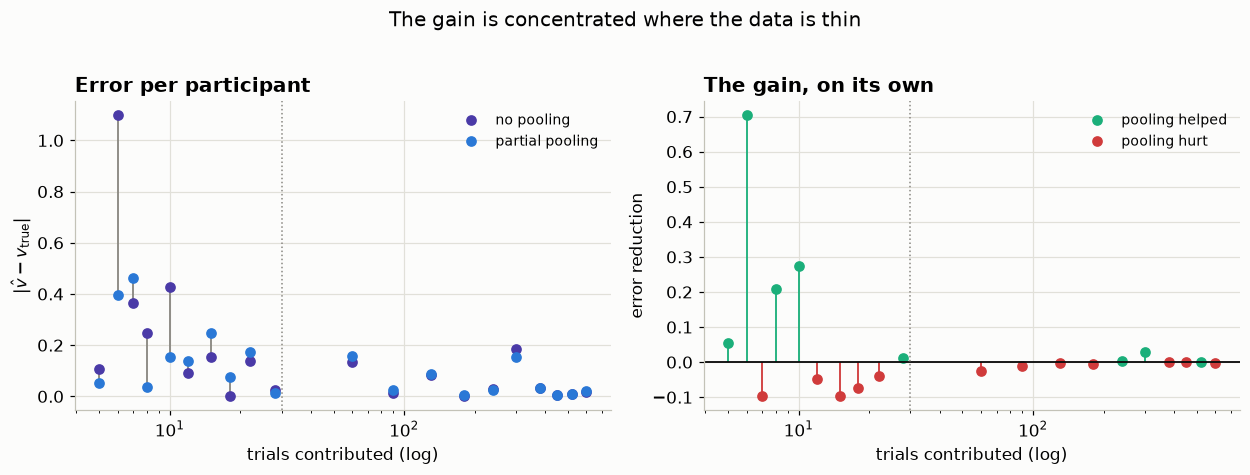

In [6]:
F.fig_pooling_error(pool)

The right panel is the gain on its own: every large bar sits left of the
dotted line, and past it the bars are invisible.

The red ones are the exceptions. Pooling drags each participant toward the
population, which overshoots whenever one genuinely sits far from it. The
guarantee is on the average — the MAE above — not on any individual.

<details class="sbi-note">
<summary>📝 <b>What pooling actually is</b></summary>

With five trials, a no-pooling estimate has almost no information, so it falls
back on whatever prior you happened to write down. Partial pooling also falls
back on a prior — but on the **population**, estimated from the participants
who did have data.

**Pooling replaces an arbitrary prior with an earned one.** That is the whole
idea, and everything after this is the price you pay for it.

</details>

> **Poll.** Partial pooling improved the sparse participants a lot and the
> dense ones not at all. Why not at all?
>
> **A.** The sampler converged better for them.
>
> **B.** Their likelihood already dominates the prior, so shrinkage has
>   almost nothing to pull against.
>
> **C.** The population distribution does not apply to them.
>
> **D.** They were closer to the population mean to begin with.

<details>
<summary>Answer</summary>

**B.** Shrinkage weight is roughly $\tau^2 / (\tau^2 + \mathrm{se}_g^2)$ — it
depends on how precise *that participant's* own estimate is. With 600 trials
the standard error is tiny, the weight goes to ~1, and the estimate barely
moves. With 5 trials the standard error is large and the population wins.

Hold on to this: the same quantity decides which **parameterization** each
group wants.

</details>

### Did we not just add parameters?

Counted naively, partial pooling is the **bigger** model — everything
no-pooling has, plus $\mu$ and $\tau$ — and it generalised better. Either
Occam's razor is wrong or we are counting the wrong thing.

<details class="sbi-note" open>
<summary>📝 <b>What <code>p_loo</code> measures</b></summary>

How many parameters the model is effectively using — *measured*, not counted:

$$
p_{\text{loo}} \;=\; (\text{fit to the data you have}) \;-\;
                     (\text{predicted fit to data you do not}),
$$

with the second term estimated by leave-one-out cross-validation.

A very flexible model fits what it saw much better than what it did not — a
**big gap**. A rigid model fits both about equally — a **small gap**. That gap
is the price of flexibility, denominated in parameters.

On a simple model with flat priors it lands near the nominal count. Anything
that **constrains** parameters — a prior, or a hierarchy — pushes it below.

</details>

In [7]:
print(f"{'':18s} {'nominal':>9s} {'effective (p_loo)':>19s}")
for key, label in [("no_pooling", "no pooling"), ("partial_pooling", "partial pooling")]:
    print(f"{label:18s} {pool['nominal'][key]:9d} {pool['p_loo'][key]:19.1f}")

                     nominal   effective (p_loo)
no pooling                20                19.2
partial pooling           22                15.1


Two more nominal parameters; roughly **four fewer effective** ones.

A parameter costs a full unit only if the data is free to put it anywhere.
Under pooling each $v_g$ is pulled toward $\mu$, so it is no longer free — it
costs a *fraction* of a parameter. The two hyperparameters are not two extra
freedoms; they are two knobs that **remove** freedom from the other twenty,
and $\tau$ is a regularisation strength *learned from the data* rather than
guessed by you.

<details class="sbi-warn" open>
<summary>⚠️ <b>Two honest caveats before you quote this number</b></summary>

**The gap depends on how sparse your groups are.** Ours has participants with
five trials, and those shrink a lot. Re-run with 600 trials for everyone and
the gap nearly closes: each participant's own data identifies their drift, and
`p_loo` approaches the nominal count. The effective-parameter story is a
statement about *your data*, not about hierarchical models in the abstract.

**`elpd_loo` was essentially a tie.** Trial-level LOO is dominated by the
participants who had plenty of trials, so it barely notices the improvement
for the sparse ones. Fewer effective parameters, same trial-level predictive
score — the benefit showed up in the **estimates**, which is what we measured
before. If you care about generalising to a *new participant*, the matching
quantity is leave-one-participant-out, not this.

</details>

<details class="sbi-note">
<summary>📝 <b>ArviZ 1.x naming</b></summary>

`az.loo(idata)` returns an object whose attribute is **`.p`**, although it
*prints* as `p_loo`. And `az.waic` no longer exists — ArviZ 1.0 removed it in
favour of PSIS-LOO. Nearly every tutorial you find online predates this.

</details>

## 2. Neal's funnel — the geometry, before any data

Neal (2003) reduced the problem to two lines:

$$v \sim \text{Normal}(0, 3), \qquad x_i \mid v \sim \text{Normal}\!\left(0, e^{v/2}\right)$$

No data, no likelihood. This is a *prior* — the shape a hierarchical model
has before data says anything. `v` is a log population scale, `x` a
group-level parameter.

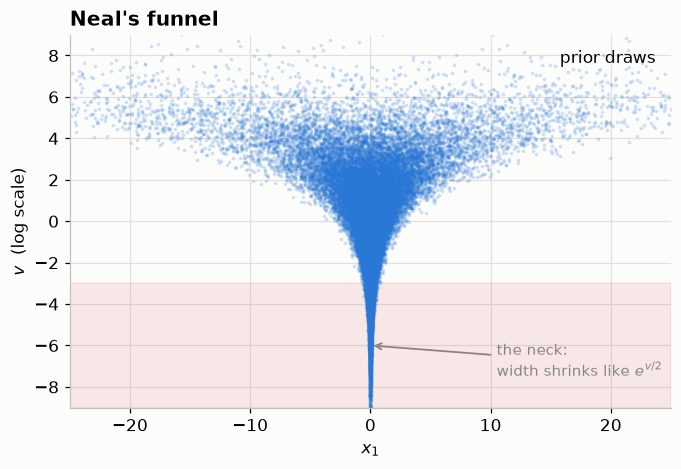

In [8]:
x_prior, v_prior = F.funnel_draws(n=40_000, sd_v=3.0, seed=RANDOM_SEED)
F.fig_funnel(x_prior, v_prior)

At $v = 2$ the conditional sd of $x$ is $e^{1} \approx 2.7$; at $v = -6$ it is
$e^{-3} \approx 0.05$, **fifty times narrower**. A step size tuned for the
mouth is unstable in the neck; one tuned for the neck crawls across the
mouth.

<details class="sbi-key" open>
<summary>🔑 <b>The failure mode is bias, not slowness</b></summary>

A sampler that cannot enter the neck does not explore it *slowly* — it never
goes there, so every posterior expectation is wrong.

</details>

## 3. Sampling it, both ways

**Centered** — sample $x$ directly, with its scale depending on $v$:

$$v \sim \text{Normal}(0,3), \qquad x \sim \text{Normal}(0, e^{v/2})$$

**Non-centered** — sample a standard normal and rescale it:

$$v \sim \text{Normal}(0,3), \qquad \tilde{x} \sim \text{Normal}(0,1),
  \qquad x = e^{v/2}\,\tilde{x}$$

The same distribution, in two coordinate systems. The sampler only ever sees
the coordinates — which is why the choice matters at all.

In [9]:
def funnel_centered(dim=1):
    with pm.Model() as m:
        v = pm.Normal("v", 0.0, 3.0)
        pm.Normal("x", 0.0, pm.math.exp(v / 2), shape=dim)
    return m


def funnel_noncentered(dim=1):
    with pm.Model() as m:
        v = pm.Normal("v", 0.0, 3.0)
        x_tilde = pm.Normal("x_tilde", 0.0, 1.0, shape=dim)
        pm.Deterministic("x", pm.math.exp(v / 2) * x_tilde)
    return m


def sample(model, seed=RANDOM_SEED, **kw):
    with model:
        return pm.sample(draws=DRAWS, tune=TUNE, chains=CHAINS, cores=1,
                         nuts_sampler="pymc", progressbar=False,
                         random_seed=seed, **kw)


idata_c = sample(funnel_centered())
idata_n = sample(funnel_noncentered())

for name, idata in [("centered", idata_c), ("non-centered", idata_n)]:
    div = int(idata.sample_stats["diverging"].values.sum())
    v = idata.posterior.dataset["v"].values
    print(f"{name:13s} divergences {div:5d}   "
          f"min v reached {v.min():6.2f}   mean v {v.mean():+.3f}  (true mean 0)")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


There were 276 divergences after tuning. Increase `target_accept` or reparameterize.


...

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v, x_tilde]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


centered      divergences   276   min v reached  -3.91   mean v +0.960  (true mean 0)
non-centered  divergences     0   min v reached -11.35   mean v +0.006  (true mean 0)


### The plot that shows it

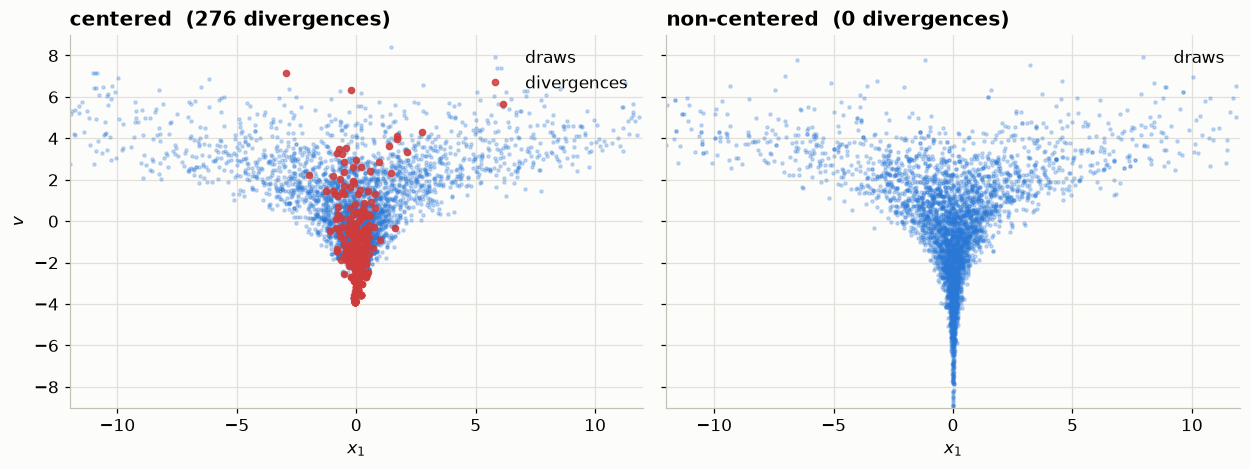

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharex=True, sharey=True)
for ax, (name, idata) in zip(axes, [("centered", idata_c), ("non-centered", idata_n)]):
    post = idata.posterior.dataset
    v = post["v"].values.ravel()
    x = post["x"].values.reshape(v.size, -1)[:, 0]
    div = idata.sample_stats["diverging"].values.ravel()
    ax.plot(x, v, "o", color=S.PRIMARY, ms=2, alpha=0.25, ls="none", label="draws")
    if div.any():
        S.divergences(ax, x[div], v[div])
    ax.set(title=f"{name}  ({int(div.sum())} divergences)",
           xlabel="$x_1$", xlim=(-12, 12), ylim=(-9, 9))
    ax.legend(loc="upper right")
axes[0].set_ylabel("$v$")
fig.tight_layout()

The divergences **cluster in the neck** — the region the centered chain then
under-samples.

> **Poll.** The centered run reports $\hat{R} = 1.00$ for `v`. What does that
> tell you?
>
> **A.** The chains converged; the divergences are a performance warning.
> **B.** Nothing useful — all four chains can fail in the same way.
> **C.** It means the model is correctly specified.
> **D.** It means we need more draws.

<details>
<summary>Answer</summary>

**B.** $\hat{R}$ compares chains to each other. If every chain stops at the
same place for the same geometric reason, they agree beautifully — about the
wrong answer. This is why divergences are a *separate* diagnostic and why
"$\hat{R}$ is fine" is not a clean bill of health.

</details>

### Proving it is bias

Efficiency problems shrink as you run longer. Bias does not.

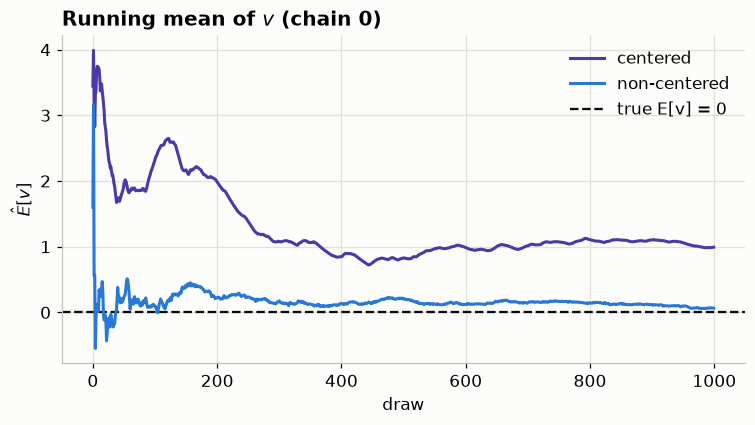

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, idata, colour in [("centered", idata_c, S.NAIVE),
                            ("non-centered", idata_n, S.PRIMARY)]:
    v = idata.posterior.dataset["v"].values[0]
    ax.plot(np.cumsum(v) / np.arange(1, v.size + 1), color=colour, label=name)
S.truth_line(ax, 0.0, label="true E[v] = 0")
ax.set(title="Running mean of $v$ (chain 0)", xlabel="draw", ylabel=r"$\hat{E}[v]$")
ax.legend()
fig.tight_layout()

The centered chain settles at the wrong value and **stays** there. Running it
ten times longer moves it ten times more slowly toward nothing in particular.

### What about just raising `target_accept`?

In [12]:
rows = []
for ta in [0.8, 0.95, 0.99]:
    idata = sample(funnel_centered(), nuts={"target_accept": ta})
    v = idata.posterior.dataset["v"].values
    rows.append({"target_accept": ta,
                 "divergences": int(idata.sample_stats["diverging"].values.sum()),
                 "min v reached": v.min(),
                 "mean v (true 0)": v.mean()})

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


There were 276 divergences after tuning. Increase `target_accept` or reparameterize.


...

NUTS: [v, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


There were 27 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [13]:
# print the table
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:8.3f}"))

 target_accept  divergences  min v reached  mean v (true 0)
         0.800          276         -3.914            0.960
         0.950          117         -5.752           -0.195
         0.990           27         -7.329            0.284


Divergences drop; the estimate does not become correct. Raising
`target_accept` suppresses the symptom, not the geometry. It is a diagnostic
aid. The fix is to change coordinates.

### Why changing coordinates fixes it

Drop the funnel's notation and use the hierarchy's:

$$
\mu \sim p(\mu), \qquad \tau \sim p(\tau), \qquad
\theta_g \mid \mu, \tau \sim \text{Normal}(\mu, \tau^2), \qquad
y_g \mid \theta_g \sim p(y_g \mid \theta_g).
$$

**Centered** means sampling $(\mu, \tau, \theta_1, \dots, \theta_G)$ — the
parameters as written. **Non-centered** means sampling
$(\mu, \tau, z_1, \dots, z_G)$ with

$$
z_g \sim \text{Normal}(0, 1), \qquad \theta_g = \mu + \tau z_g .
$$

The map is a bijection for any fixed $\tau > 0$, with constant Jacobian
$\partial \theta_g / \partial z_g = \tau$, so the two describe **the same
posterior**. Nothing statistical changes. What changes is the surface the
sampler walks on.

### The prior term is the whole story

Write down the prior contribution in each coordinate system. Centered:

$$
\log p(\theta_g \mid \mu, \tau) =
-\log \tau - \frac{(\theta_g - \mu)^2}{2\tau^2} + \text{const}.
$$

That expression **couples $\theta_g$ to $\tau$**: the width of the band
$\theta_g$ may occupy *is* $\tau$ — a sliver at small $\tau$, wide at large.
Plot the admissible set over $(\log \tau, \theta_g)$ and you get the funnel
from section 2 — narrow neck, wide mouth.

Non-centered:

$$
\log p(z_g) = -\frac{z_g^2}{2} + \text{const}.
$$

**No $\tau$.** The prior geometry of $z_g$ is a unit Gaussian whatever $\tau$
does, so $z$ and $\tau$ are *a priori independent* and the funnel is gone —
not tamed, absent. The $\tau$-dependence has been moved out of the geometry
and into the deterministic line $\theta_g = \mu + \tau z_g$, which the sampler
never has to explore.

### Why a sampler cares about the shape at all

HMC and NUTS discretise a trajectory with **one step size** and one mass
matrix for the whole space. A step size is a claim about the scale of the
distribution, and a funnel has no single scale: a step that suits the mouth
overshoots the neck and the integrator diverges.

So the chain does not sample the neck badly — it fails to enter it, and every
expectation comes out biased, as section 3 measured. Non-centering does not
make the sampler cleverer. It hands it a space where one step size is
defensible everywhere.

### And why it is not free

The likelihood has been silent so far. Reinstate it, in non-centered
coordinates:

$$
\log p(y_g \mid \mu + \tau z_g).
$$

Now $z_g$ and $\tau$ appear **together in the likelihood**. When $y_g$ carries
real information about $\theta_g$, it pins the *product* $\mu + \tau z_g$, so
raising $\tau$ must be met by shrinking $z_g$ — a fresh correlation, in the
coordinates we adopted to remove one.

Take group $g$ observed with standard error $\sigma_g$, and hold $\mu$ and
$\tau$ fixed. Prior and likelihood are both Gaussian in $z_g$, so the
conditional is too, with

$$
\operatorname{sd}(z_g \mid \tau) \;=\;
\frac{\sigma_g}{\sqrt{\sigma_g^{2} + \tau^{2}}}
\;\;\xrightarrow[\;\tau \gg \sigma_g\;]{}\;\; \frac{\sigma_g}{\tau} .
$$

Read the two ends. When $\tau \ll \sigma_g$ the width is $1$ — the prior, flat
in $\tau$, which is the good case we just built. When $\tau \gg \sigma_g$ the
width **pinches shut like $1/\tau$**.

A funnel again, upside down: the centered one closes at the *bottom* of
$\log\tau$, the non-centered one at the *top*. Which end you live at is
decided by $\sigma_g$ — whether group $g$'s own data is precise relative to
how much the groups differ.

That is the whole trade:

| | prior term | likelihood term | so |
|---|---|---|---|
| **centered** | couples $\theta_g$ to $\tau$ — funnel at small $\tau$ | clean, sees $\theta_g$ directly | good when data dominates |
| **non-centered** | independent of $\tau$ — no funnel | couples $z_g$ to $\tau$ — funnel at large $\tau$ | good when the prior dominates |

Neither is correct in general.

## 4. Non-centered is not always better

Which one wins depends on whether the **prior** or the **likelihood**
dominates each group's posterior (Papaspiliopoulos, Roberts & Sköld 2007;
Betancourt & Girolami 2013). Rather than take the crossover on faith, measure
it: a hierarchical normal, swept well past it, because the far side is half
the lesson.

In [14]:
# Two axes, not one. The NUMBER of groups is a second knob on the same geometry
# — every group adds a theta that must fit through the same neck — so the sweep
# runs at two panel sizes.
GROUP_COUNTS = [8, 24]
OBS_PER_GROUP = [1, 3, 10, 30, 100, 300, 1000]      # well past the crossover
TRUE_MU, TRUE_TAU, OBS_SIGMA = 0.0, 1.0, 1.0


def make_groups(n_groups, obs_per_group, seed):
    g = np.random.default_rng(seed)
    theta = g.normal(TRUE_MU, TRUE_TAU, n_groups)
    y = g.normal(theta[:, None], OBS_SIGMA, (n_groups, obs_per_group))
    return y.mean(axis=1), OBS_SIGMA / np.sqrt(obs_per_group)


def hier_centered(y_bar, se):
    with pm.Model() as m:
        mu = pm.Normal("mu", 0.0, 5.0)
        tau = pm.HalfNormal("tau", 5.0)
        theta = pm.Normal("theta", mu, tau, shape=y_bar.size)
        pm.Normal("y", theta, se, observed=y_bar)
    return m


def hier_noncentered(y_bar, se):
    with pm.Model() as m:
        mu = pm.Normal("mu", 0.0, 5.0)
        tau = pm.HalfNormal("tau", 5.0)
        z = pm.Normal("z", 0.0, 1.0, shape=y_bar.size)
        theta = pm.Deterministic("theta", mu + tau * z)
        pm.Normal("y", theta, se, observed=y_bar)
    return m


sweep = []
for n_groups in GROUP_COUNTS:
    for obs in OBS_PER_GROUP:
        y_bar, se = make_groups(n_groups, obs, seed=RANDOM_SEED + obs)
        for label, builder in [("centered", hier_centered),
                               ("non-centered", hier_noncentered)]:
            idata = sample(builder(y_bar, se))
            grads = idata.sample_stats["n_steps"].values.sum() \
                if "n_steps" in idata.sample_stats else np.nan
            ess = float(az.ess(idata, var_names=["tau"]).tau)
            sweep.append({"groups": n_groups, "obs/group": obs, "param": label,
                          "divergences": int(idata.sample_stats["diverging"].values.sum()),
                          "ESS(tau)": ess,
                          "ESS per 1k grads": 1000 * ess / grads if grads == grads else np.nan})

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, tau, theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


There were 236 divergences after tuning. Increase `target_accept` or reparameterize.


...

NUTS: [mu, tau, z]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [15]:
sweep = pd.DataFrame(sweep)
for n_groups in GROUP_COUNTS:
    print(f"\n--- {n_groups} groups " + "-" * 44)
    print(sweep[sweep.groups == n_groups].drop(columns="groups")
          .to_string(index=False, float_format=lambda x: f"{x:9.2f}"))


--- 8 groups --------------------------------------------
 obs/group        param  divergences  ESS(tau)  ESS per 1k grads
         1     centered          236     15.41              0.38
         1 non-centered            4    906.91             21.12
         3     centered           15   1969.23             72.26
         3 non-centered            0    948.44             23.50
        10     centered            0   3224.16            121.75
        10 non-centered            0    686.19             13.14
        30     centered            0   3919.49            151.61
        30 non-centered            2    662.00             10.21
       100     centered            0   3498.52            139.22
       100 non-centered           10    316.76              2.87
       300     centered            0   3410.09            140.75
       300 non-centered           13    398.06              2.23
      1000     centered            0   3935.28            159.89
      1000 non-centered        

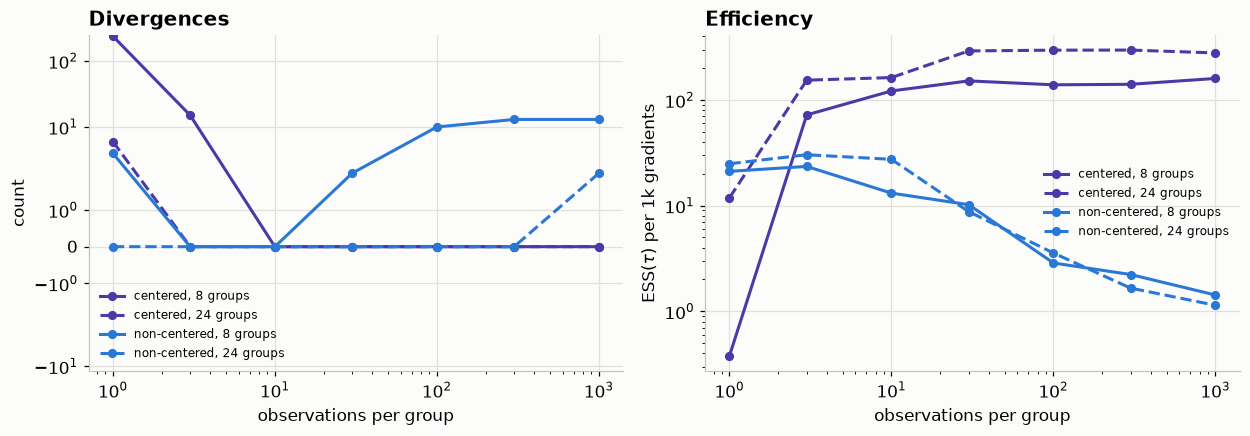

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.1))
for label, colour in [("centered", S.NAIVE), ("non-centered", S.PRIMARY)]:
    for n_groups, style in zip(GROUP_COUNTS, ["-", "--"]):
        sub = sweep[(sweep.param == label) & (sweep.groups == n_groups)]
        tag = f"{label}, {n_groups} groups"
        ax1.plot(sub["obs/group"], sub["divergences"], "o" + style, color=colour,
                 label=tag, ms=5)
        ax2.plot(sub["obs/group"], sub["ESS per 1k grads"], "o" + style,
                 color=colour, label=tag, ms=5)
ax1.set(title="Divergences", xlabel="observations per group", xscale="log",
        yscale="symlog", ylabel="count")
ax1.legend(fontsize=8)
ax2.set(title="Efficiency", xlabel="observations per group", xscale="log",
        yscale="log", ylabel=r"ESS($\tau$) per 1k gradients")
ax2.legend(fontsize=8)
fig.tight_layout()

Read the right-hand panel first, and note the **log** vertical axis. The two
curves cross almost immediately — non-centered wins only in the sparsest
column, at one observation per group — and then separate: by 1000 observations
per group, centering is worth a **hundredfold to two-hundredfold** difference
in ESS per unit of work, depending on panel size. The far end of this sweep is
not a curiosity; it is where a lot of real cognitive data sits.

<details class="sbi-note">
<summary>📝 <b>The rule, stated properly</b></summary>

"Always non-center hierarchical models" is the single most widespread piece of
wrong advice in applied Bayesian work. The correct statement is: **non-center
the parameters whose groups are data-poor.**

Which is why you want the choice to be **per parameter**.

</details>

<details class="sbi-key" open>
<summary>🔑 <b>More groups suppresses the divergences without fixing the efficiency</b></summary>

Compare the solid lines (8 groups) with the dashed ones (24). Divergences
largely **disappear** on the bigger panel: the centered fit at one observation
per group falls from 236 divergences to 6, and the non-centered fit's
complaints at the data-rich end (10, 13, 13) drop to (0, 0, 2).

That is not the geometry being repaired. It is Betancourt's remark, now
readable off a figure: **more groups means more information about $\tau$,
which trims off the extreme values of $\tau$ where the pathology lives.**

The efficiency panel keeps its shape and its ordering throughout. So a clean
divergence count is *not* evidence you chose the right parameterization — only
that you had enough groups to hide the wrong one. Judge by ESS per gradient,
and let divergences tell you about correctness rather than about cost.

</details>

### What that looks like in the geometry

The ESS curves say *that* the advantage reverses; this says *why*. Four fits —
both parameterizations, at weak and strong data — each in the coordinates its
own sampler works in, against $\log\tau$, divergences overlaid. Rubin's eight
schools, unmodified.

Two details of the setup are load-bearing; get either wrong and the
bottom-right panel looks harmless when it is not.

**Which group gets plotted.** The non-centered ridge is
$z_g = (y_g - \mu)/\tau$, so its slope against $\log\tau$ is $-z_g$ — a group
sitting near the population mean draws a flat blob however bad the geometry
is. We plot the group furthest from the mean, chosen from the data so that
both columns show the same school.

**The prior on $\tau$.** `HalfNormal(25)`, not the customary `HalfNormal(5)`.
The schools' effects run to 28 points and the strong-likelihood posterior for
$\tau$ sits near 10, so a scale of 5 truncates $\tau$'s *upper* tail — which
is exactly where the non-centered form pinches. Same data, same code, that one
number changed: **2 divergences becomes 88**, while the centered fit reports
zero either way. A prior tight enough to hide a pathology is not weakly
informative, whatever it says on the tin.

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, tau, theta]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.


There were 466 divergences after tuning. Increase `target_accept` or reparameterize.


...

Sequential sampling (4 chains in 1 job)


NUTS: [mu, tau, z]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 6 seconds.


There were 88 divergences after tuning. Increase `target_accept` or reparameterize.


8 groups


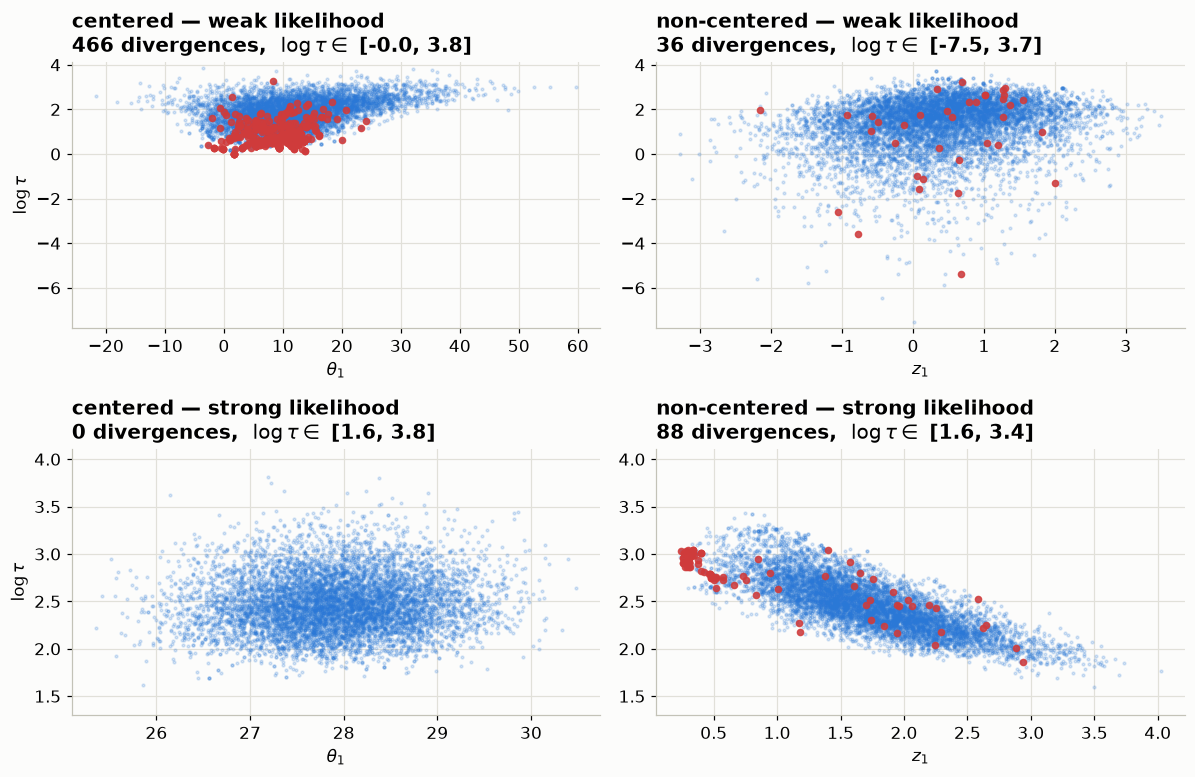

In [17]:
geom = F.geometry_experiment(seed=RANDOM_SEED)
print(f"{geom['n_groups']} groups")
F.fig_geometry_grid(geom)

In [18]:
print(f"{'parameterization':16s} {'se scale':>9s} {'divergences':>12s} "
      f"{'log tau reached':>17s} {'ESS(tau)':>10s} {'corr w/ log tau':>16s}")
for (scale, par), d in geom["results"].items():
    span = f"{d['min_log_tau']:6.2f} .. {d['max_log_tau']:5.2f}"
    print(f"{par:16s} {scale:9g} {d['n_divergences']:12d} "
          f"{span:>17s} {d['ess_tau']:10.1f} {d['corr']:16.2f}")

parameterization  se scale  divergences   log tau reached   ESS(tau)  corr w/ log tau
centered                 1          466    -0.01 ..  3.84      135.6             0.37
non-centered             1           36    -7.52 ..  3.72     2575.2             0.20
centered              0.05            0     1.62 ..  3.81     7011.2             0.07
non-centered          0.05           88     1.60 ..  3.43      820.6            -0.78


**The two panels in each row share a $\log\tau$ axis** — that is what makes
the comparison honest.

**Top row (weak likelihood).** The centered chain simply *stops* at
$\log\tau \approx 0$, with hundreds of divergences piled against that floor,
and reports $\hat{R} \approx 1$ while doing it. The non-centered chain, on the
same axis, carries on down past $-7$.

**Bottom row (strong likelihood).** Everything swaps, and this is the panel to
look at hardest. Centered collapses to a round blob: the data pins $\theta_1$
near 28, $\tau$ has stopped mattering to it, correlation **+0.07**, zero
divergences. Non-centered has bent into a curved band with correlation
**−0.78** — that is $z_1 = (y_1 - \mu)/\tau$ traced out as $\tau$ moves, the
coupling we changed coordinates to get rid of, back again. It throws **88
divergences**, and they are not scattered: they sit at the **87th percentile**
of $\log\tau$, piled against the top of the band exactly as the centered
chain's pile against the bottom of the neck. It also stops climbing at
$\log\tau = 3.4$ where the centered chain reaches $3.8$.

That is section 3's trade table, measured: the same pathology in the opposite
corner of the grid, at the opposite end of $\tau$. In both rows the tell is
identical — **the failing chain cannot reach where the healthy one goes.**

<details class="sbi-note">
<summary>📝 <b>Why the bottom-right band does not visibly taper</b></summary>

The derivation says $\operatorname{sd}(z_g \mid \tau) \to \sigma_g/\tau$, so
you might expect that band to close like a wedge. It does not — measured
across quartiles of $\log\tau$, its width is 0.46, 0.37, 0.37, 0.39.

Because the panel is a **marginal**, and $\mu$ is free in it. With
$z_g = (\theta_g - \mu)/\tau$ and $\mu$ carrying posterior sd
$\tau/\sqrt{G}$, $\mu$ alone contributes $1/\sqrt{G} = 0.35$ to the width of
$z_g$ — the same at every $\tau$. The $\sigma_g/\tau$ pinch runs from 0.15
down to 0.02 underneath that and is simply swamped.

The conditional funnel is real and it is what the sampler feels. The marginal
shows it as **curvature and correlation** instead of as a taper. Worth
remembering generally: a 2-D marginal is not the geometry, it is a shadow of
it.

</details>

<details class="sbi-note">
<summary>📝 <b>Why the panel is eight groups</b></summary>

Because the group count only affects one of the two pathologies, and in the
direction that hides it — the effect the sweep's divergence panel showed
above, now playing out on the other parameterization.

Re-run the whole grid at 8 / 16 / 32 / 64 groups. The centered fit under a
weak likelihood barely notices (466, 309, 343, 77 divergences). The
non-centered fit under a strong likelihood does this:

| groups | 8 | 16 | 32 | 64 |
|---|---|---|---|---|
| divergences | **88** | 21 | 2 | **0** |
| ESS($\tau$) | **821** | 565 | 311 | **163** |

The divergences vanish while the efficiency gets five times *worse*. More
groups does not repair the geometry; it pins $\tau$ and removes the extreme
values that expose it — Betancourt's **"the pathological behavior is the worst
exactly when the partial pooling is strongest."**

Eight groups is where the reversal costs you correctness, which is why the
figure uses eight. At the group counts you will actually have, expect it to
cost you silently.

</details>

<details class="sbi-warn" open>
<summary>⚠️ <b>Do not memorise the crossover point</b></summary>

The crossover moves with the number of groups, the group-scale prior, and how
much the groups actually differ — so "the crossover is between 1 and 3
observations per group" is a fact about *this* setup, not a constant. You saw
two of those dependencies measured on this page: the panel size took the
non-centered divergence count from 88 to 0, and the prior scale on $\tau$ took
it from 2 to 88.

What transfers is the *shape*: two curves that cross, and a rule for which
side you are on. Run the sweep on your own model rather than importing a
number from someone else's.

</details>

## 5. Per-parameter parameterization in HSSM

A real SSM has parameters of both kinds in the same model. Drift `v` is often
estimated from plenty of trials per participant; a boundary or non-decision
time may be far more weakly identified. HSSM lets you choose independently.

In [19]:
import hssm

data = hssm.load_data("cavanagh_theta")
print(data.head(3).to_string(index=False))
print("\nparticipants:", data["participant_id"].nunique(), " trials:", len(data))

 participant_id stim   rt  response     theta  dbs conf
              0   LL 1.21       1.0  0.656275    1   HC
              0   WL 1.63       1.0 -0.327889    1   LC
              0   WW 1.03       1.0 -0.480285    1   HC

participants: 14  trials: 3988


`noncentered` is not an HSSM argument — it passes straight through to
`bmb.Model`. It takes a bool **or a dict keyed by parameter**, and a
per-prior setting overrides the dict:

```
resolution order:  prior.noncentered  >  noncentered[param]  >  True
```

In [20]:
def build(noncentered):
    return hssm.HSSM(
        data=data,
        model="ddm",
        noncentered=noncentered,
        include=[
            {"name": "v", "formula": "v ~ 1 + (1|participant_id)"},
            {"name": "a", "formula": "a ~ 1 + (1|participant_id)"},
        ],
        p_outlier=0.05,          # explicit: this is the default, not "off"
        prior_settings="safe",
    )


mixed = build({"v": False, "a": True})

# The PyMC graph is materialised at construction — no `.build()` to call.
participant_nodes = sorted(n for n in mixed.pymc_model.named_vars
                           if "participant_id" in n)
print("participant-level nodes:")
for n in participant_nodes:
    mark = "  <- non-centered" if n.endswith("_offset") else ""
    print(f"    {n}{mark}")

Model initialized successfully.


participant-level nodes:
    a_1|participant_id
    a_1|participant_id_offset  <- non-centered
    a_1|participant_id_sigma
    v_1|participant_id
    v_1|participant_id_sigma


The `_offset` nodes are the structural fingerprint of the non-centered
parameterization: `u_g = z_g · σ`. `a` has one, `v` does not — read off the
graph, without sampling anything.

<details class="sbi-warn" open>
<summary>⚠️ <b>Two ways this bites</b></summary>

**Non-centering only works for `Normal` priors whose `sigma` is itself a
random variable:**

Anything else raises `NotImplementedError` when the model
is built — loud, at least.

**Check for disconnected nodes:**

A `Normal` group prior with a nested `mu` hyperprior under
non-centering leaves `mu` as a **disconnected free variable** — sampled, but
influencing nothing. HSSM 0.4.0 ships detectors for this
(`check_user_priors_against_parameterization`, `find_disconnected_free_rvs`).
Always check `print(model)` / `model.graph()` after changing parameterization,
because term-prior keys differ between the two forms and a mismatched key is
**silently dropped**.

</details>

### Where per-parameter runs out

The choice is per *random effect*, so every group inside one effect gets the
same treatment — and groups can disagree. Betancourt's example: nine groups
with $N = (10, 5, \mathbf{1000}, 10, 1, 5, \mathbf{100}, 10, 5)$. Center
everything and the sparse groups funnel; non-center everything and the two
rich ones inverted-funnel. The right answer there is **per group**, which no
API on this page exposes.

And it is quiet. Both monolithic fits on that panel diverge at rates of
**0.015%** and **0.005%** — a handful out of thousands, the kind you would
wave away. The aggregate count averages over groups, and two broken groups out
of nine do not move it. You find them the way section 4 did: plot $\theta_g$
or $z_g$ against $\log\tau$ **one group at a time**.

The fix — split the groups at a size threshold and parameterize each half its
own way — needs per-group surgery on the model.

### Exercise

Build the same model with `noncentered=True` and with `noncentered=False`, and
confirm from the graph alone (no sampling) which nodes change. Then predict —
before running anything — which setting you would want for `v` in the Cavanagh
data, given its 3,988 trials spread over 14 participants.

<details>
<summary>Solution and reasoning</summary>

```python
for setting in [True, False]:
    m = build(setting)
    offs = sorted(n for n in m.pymc_model.named_vars if n.endswith("_offset"))
    print(setting, "->", offs)
```

With roughly 285 trials per participant, the drift rate is well identified
*within* each participant — the likelihood dominates, so **centered** is the
better choice for `v`. Parameters that are weakly constrained per participant,
or a group scale estimated from only 14 groups, are the ones that want
non-centering. This is the crossover from section 4, in a real model.

</details>

## 6. The capstone: a slope per participant

Section 1 gave every participant their own *drift*. But drift usually
**varies within a participant** with some manipulation, so give every
participant a **slope** as well:

$$v_{gi} \;=\; \beta^{(g)}_0 \;+\; \beta^{(g)}_1 \cdot \text{difficulty}_i,
  \qquad
  \beta^{(g)}_0, \beta^{(g)}_1 \sim \text{Normal}(\mu_\beta, \tau_\beta)$$

Same brutal panel — trial counts from 5 to 600 — and difficulty varies
continuously from trial to trial.

A slope is *harder* than an intercept. It needs enough trials **and** enough
spread in the covariate. With five trials you have neither.

In [21]:
reg = F.regression_experiment(seed=RANDOM_SEED)

for name in ("intercept", "slope"):
    s = F.pooling_summary(reg[name])
    print(f"{name:10s} MAE  n<30: {s['no_pooling']['mae_low']:.3f} -> "
          f"{s['partial_pooling']['mae_low']:.3f}"
          f"   |  n>=30: {s['no_pooling']['mae_high']:.3f} -> "
          f"{s['partial_pooling']['mae_high']:.3f}"
          f"   |  {s['low_n_improvement_pct']:.0f}% better where thin")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [b0, b1]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu_b0, tau_b0, mu_b1, tau_b1, z0, z1]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


intercept  MAE  n<30: 0.354 -> 0.184   |  n>=30: 0.050 -> 0.047   |  48% better where thin
slope      MAE  n<30: 0.598 -> 0.229   |  n>=30: 0.100 -> 0.106   |  62% better where thin


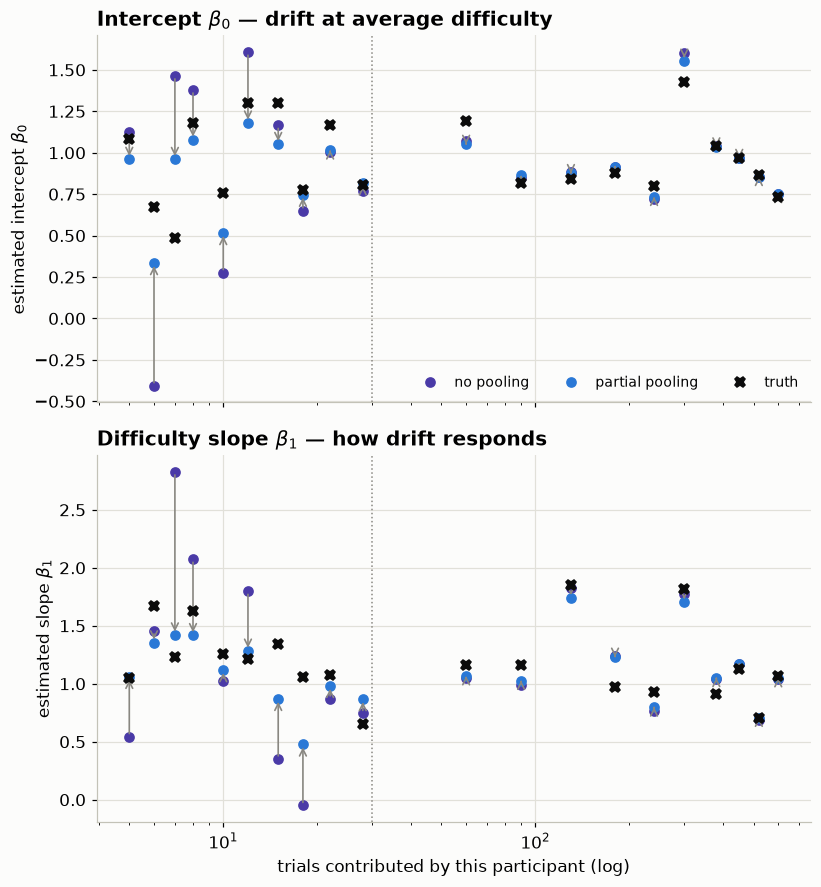

In [22]:
# Both quantities, stacked on a shared x-axis: read straight down and you are
# looking at the same participant twice.
fig, axes = plt.subplots(2, 1, figsize=(7.6, 8.2), sharex=True)
F.fig_shrinkage(reg["intercept"], ax=axes[0],
                ylabel=r"estimated intercept $\beta_0$",
                title=r"Intercept $\beta_0$ — drift at average difficulty")
F.fig_shrinkage(reg["slope"], ax=axes[1], legend=False,
                ylabel=r"estimated slope $\beta_1$",
                title=r"Difficulty slope $\beta_1$ — how drift responds")
axes[0].set_xlabel("")
fig.tight_layout()

Look at the left-hand side of each panel. Neither quantity survives five
trials: the worst intercept lands at **−0.4** where the truth is 0.67, and the
worst slope at **2.9** where the truth is 1.23, with another at essentially
**zero** where the truth is 1.06. Those are not estimates, they are noise with
a credible interval attached.

The slope is the worse of the two — MAE **0.60** against the intercept's
**0.35** where trials are thin — and it is the one pooling rescues hardest.
On the right-hand side both panels agree: participants who spoke for
themselves are left alone.

<details class="sbi-note">
<summary>📝 <b>Why the slope gains more than the intercept</b></summary>

The improvement where trials are thin is around **48%** for the intercept and
around **62%** for the slope — the numbers behind the two panels above. The
slope gains more because it needs the covariate to have moved *within* that
participant.

This is the practical argument for hierarchy in cognitive modelling. It is
rarely "we want a population estimate". It is "we want per-participant
estimates, and some of our participants are thin."

</details>

<details class="sbi-warn" open>
<summary>⚠️ <b>What pooling is not</b></summary>

It does not manufacture information. The rescued slopes are **closer** to the
truth, not correct — look at how far the five-trial participants still sit
from their black crosses. Pooling buys you a defensible estimate where you
would otherwise have had a wild one; it does not buy you the experiment you
failed to run.

</details>

### Exercise

The panel fixes `a`, `z` and `t` so the comparison is about `v` alone. Give
the boundary `a` a per-participant random effect too, and predict — before
running it — whether pooling helps `a` more or less than it helped the slope.

<details>
<summary>What to expect, and why</summary>

`a` is identified through the *speed–accuracy relationship* rather than
through trial count alone, so adding trials helps it more slowly than it helps
`v` — even the data-rich participants stay somewhat prior-dependent, and
pooling keeps earning its keep further to the right of the plot.

Same point as section 5: **different parameters are informed by different
amounts of the same data.** If you find `a` still shrinking hard at 600
trials, that is your evidence that `a` wants a non-centered parameterization
while `v` does not.

</details>

### References

- Neal, R. (2003). Slice sampling. *Annals of Statistics* 31(3), 705–767.
- Papaspiliopoulos, Roberts & Sköld (2007). A general framework for the
  parametrization of hierarchical models. *Statistical Science* 22(1), 59–73.
- Betancourt & Girolami (2013). Hamiltonian Monte Carlo for hierarchical
  models. [arXiv:1312.0906](https://arxiv.org/abs/1312.0906) — the source of
  the weak/strong likelihood manipulation used in the geometry grid.
- Betancourt (2017). Diagnosing biased inference with divergences.
- Betancourt (2020). [Hierarchical
  modeling](https://betanalpha.github.io/assets/case_studies/hierarchical_modeling.html)
  — the long-form version of section 4, including why the prior on $\tau$ has
  to be chosen so that it does not hide the geometry.
- Gorinova, Moore & Hoffman (2020). Automatic reparameterisation of
  probabilistic programs. *ICML*.